# 02 — Synthetic Safety Score Generation

**DESIGN.md §2A / §5.2**: *Generate synthetic training data, fit the PyTorch MLP (`safety_net.pth`).*

This notebook:
1. Loads the H3 grid features from `data/patna_h3_grid_features.csv` (output of notebook 01)
2. Applies a **domain-grounded heuristic function** to compute a synthetic `target_safety_score ∈ [0, 1]`
3. Adds calibrated **Gaussian noise** for model robustness
4. Validates the resulting distribution
5. Exports the final training dataset to `data/patna_synthetic_training_data.csv`

### Heuristic Design Rationale

Since we do not have ground-truth safety labels, we construct a **proxy score** using
infrastructure density as a safety indicator. The core assumption (DESIGN.md §2A):

> Areas with **high infrastructure density** (police, hospitals, schools, commercial activity,
> well-connected intersections) are **safer** than isolated, sparsely-served areas.

The heuristic assigns **weighted contributions** to each POI category based on their
empirical relevance to urban safety, then normalises and adds noise.

In [1]:
# ── Imports ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
np.random.seed(42)  # Reproducibility

print('Libraries loaded.')

Libraries loaded.


## 1. Load the H3 Grid Feature Data

In [2]:
# ── Load the CSV produced by notebook 01 ────────────────
DATA_PATH = '../data/patna_h3_grid_features.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} H3 cells from {DATA_PATH}')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded 422 H3 cells from ../data/patna_h3_grid_features.csv
Columns: ['hex_id', 'centroid_lat', 'centroid_lng', 'count_hospital', 'count_police', 'count_residential', 'count_commercial', 'count_hotel', 'count_fire_station', 'count_school', 'count_bank', 'count_bus_stop', 'count_intersections', 'total_poi_count', 'density_norm']


,hex_id,centroid_lat,centroid_lng,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections,total_poi_count,density_norm
0,883c138c51fffff,25.635425,85.074312,0,0,0,0,0,0,0,0,0,67,67,0.226351
1,883c13b985fffff,25.608367,85.260723,0,0,0,0,0,0,0,0,0,0,0,0.000000
2,883c138dcdfffff,25.577782,85.071630,1,0,0,0,0,0,0,0,0,142,143,0.483108
3,883c138db1fffff,25.549404,85.117196,1,0,0,0,0,0,0,0,0,125,126,0.425676
4,883c13b825fffff,25.636863,85.224513,0,0,0,0,0,0,0,0,0,0,0,0.000000


In [3]:
# ── Identify the 10 feature columns ─────────────────────
FEATURE_COLS = [
    'count_hospital',
    'count_police',
    'count_residential',
    'count_commercial',
    'count_hotel',
    'count_fire_station',
    'count_school',
    'count_bank',
    'count_bus_stop',
    'count_intersections',
]

print(f'Feature columns ({len(FEATURE_COLS)}):')
for col in FEATURE_COLS:
    total = df[col].sum()
    nonzero = (df[col] > 0).sum()
    print(f'  {col:25s}  total={total:>6,}  |  non-zero cells: {nonzero:>4} / {len(df)}')

Feature columns (10):
  count_hospital             total=   273  |  non-zero cells:   84 / 422
  count_police               total=    19  |  non-zero cells:   15 / 422
  count_residential          total=   147  |  non-zero cells:   40 / 422
  count_commercial           total=   748  |  non-zero cells:   76 / 422
  count_hotel                total=    34  |  non-zero cells:   21 / 422
  count_fire_station         total=     0  |  non-zero cells:    0 / 422
  count_school               total=    93  |  non-zero cells:   50 / 422
  count_bank                 total=   156  |  non-zero cells:   49 / 422
  count_bus_stop             total=    11  |  non-zero cells:    8 / 422
  count_intersections        total=23,140  |  non-zero cells:  229 / 422


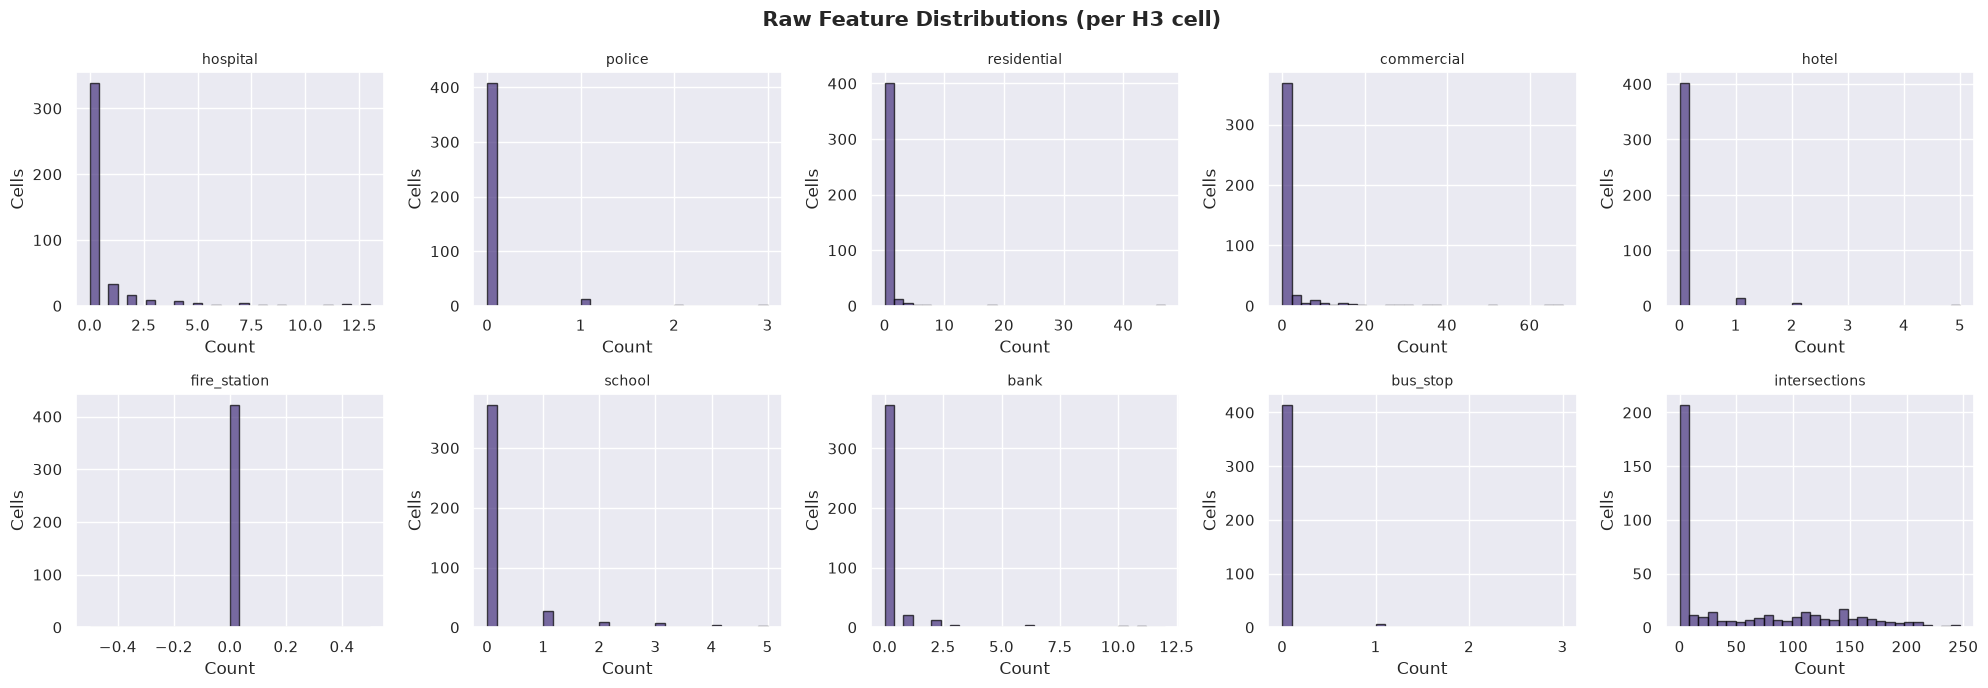

In [4]:
# ── Quick distribution of raw feature counts ────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Raw Feature Distributions (per H3 cell)', fontsize=15, fontweight='bold')

for ax, col in zip(axes.ravel(), FEATURE_COLS):
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col.replace('count_', ''), fontsize=10)
    ax.set_xlabel('Count')
    ax.set_ylabel('Cells')

plt.tight_layout()
plt.show()

## 2. Define the Heuristic Safety Function

We assign **domain-informed weights** to each infrastructure category.
The philosophy:

| Weight | Category | Safety Logic |
|--------|----------|-------------|
| **High (0.20)** | `police` | Direct safety enforcement presence |
| **High (0.15)** | `hospital` | Emergency medical access |
| **Medium (0.12)** | `commercial` | High footfall = more natural surveillance |
| **Medium (0.12)** | `intersections` | Better connectivity = more escape routes, better lit |
| **Medium (0.10)** | `residential` | Population density = passive surveillance |
| **Medium (0.08)** | `school` | Institutional presence, usually well-monitored |
| **Low (0.08)** | `bus_stop` | Public transport access, moderate footfall |
| **Low (0.06)** | `bank` | Security presence (ATMs, guards) |
| **Low (0.05)** | `hotel` | Some footfall, lighting, but variable quality |
| **Low (0.04)** | `fire_station` | Emergency service, but rare and indirect impact |

**Total weights = 1.00** (a convex combination).

### Scoring Pipeline
1. **Per-feature normalisation**: Min-max scale each feature column to [0, 1]
2. **Weighted sum**: Compute `raw_score = Σ(w_i × normalised_feature_i)`
3. **Sigmoid stretch**: Apply a logistic curve to push the distribution away from the extremes
4. **Gaussian noise**: Add N(0, σ²) noise and clamp to [0, 1]

In [5]:
# ── Heuristic weights (sum = 1.0) ──────────────────────
HEURISTIC_WEIGHTS = {
    'count_police':        0.20,
    'count_hospital':      0.15,
    'count_commercial':    0.12,
    'count_intersections': 0.12,
    'count_residential':   0.10,
    'count_school':        0.08,
    'count_bus_stop':      0.08,
    'count_bank':          0.06,
    'count_hotel':         0.05,
    'count_fire_station':  0.04,
}

assert abs(sum(HEURISTIC_WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1.0'
print('Heuristic weights defined (sum = 1.00):')
for k, v in sorted(HEURISTIC_WEIGHTS.items(), key=lambda x: -x[1]):
    print(f'  {k:25s}  -  {v:.2f}')

Heuristic weights defined (sum = 1.00):
  count_police               -  0.20
  count_hospital             -  0.15
  count_commercial           -  0.12
  count_intersections        -  0.12
  count_residential          -  0.10
  count_school               -  0.08
  count_bus_stop             -  0.08
  count_bank                 -  0.06
  count_hotel                -  0.05
  count_fire_station         -  0.04


In [6]:
# ── Step 1: Min-Max normalise each feature to [0, 1] ───
df_norm = df[FEATURE_COLS].copy()

for col in FEATURE_COLS:
    col_min = df_norm[col].min()
    col_max = df_norm[col].max()
    if col_max > col_min:
        df_norm[col] = (df_norm[col] - col_min) / (col_max - col_min)
    else:
        # All values identical (e.g., fire_station might be all 0)
        df_norm[col] = 0.0

print('Min-max normalisation complete.')
df_norm.describe().round(3)

Min-max normalisation complete.


,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections
count,422.000,422.000,422.000,422.000,422.000,422.0,422.000,422.000,422.000,422.000
mean,0.050,0.015,0.007,0.026,0.016,0.0,0.044,0.031,0.009,0.222
std,0.146,0.086,0.054,0.101,0.088,0.0,0.145,0.125,0.070,0.275
min,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.040
75%,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.449
max,1.000,1.000,1.000,1.000,1.000,0.0,1.000,1.000,1.000,1.000


In [7]:
# ── Step 2: Weighted sum → raw_score ───────────────────
df['raw_score'] = sum(
    HEURISTIC_WEIGHTS[col] * df_norm[col]
    for col in FEATURE_COLS
)

print(f'Raw score range: [{df["raw_score"].min():.4f}, {df["raw_score"].max():.4f}]')
print(f'Raw score mean:  {df["raw_score"].mean():.4f}')
print(f'Raw score std:   {df["raw_score"].std():.4f}')

Raw score range: [0.0000, 0.6430]
Raw score mean:  0.0479
Raw score std:   0.0798


In [8]:
# ── Step 3: Sigmoid stretch for better spread ──────────
# A logistic function centred on the mean of raw_score pushes
# the distribution away from clustering at 0 or 1.
#
# sigmoid(x) = 1 / (1 + exp(-k * (x - x0)))
#   k  = steepness (higher = sharper transition)
#   x0 = centre point (use the median of raw_score)

def sigmoid_stretch(x: pd.Series, k: float = 10.0) -> pd.Series:
    """Apply a logistic stretch centred on the median."""
    x0 = x.median()
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))

df['stretched_score'] = sigmoid_stretch(df['raw_score'], k=10.0)

print(f'Stretched score range: [{df["stretched_score"].min():.4f}, {df["stretched_score"].max():.4f}]')
print(f'Stretched score mean:  {df["stretched_score"].mean():.4f}')

Stretched score range: [0.4879, 0.9983]
Stretched score mean:  0.5849


In [9]:
# ── Step 4: Add Gaussian noise ─────────────────────────
# σ = 0.05 gives ±2σ ≈ 0.10 variation — enough to prevent
# the DNN from memorising exact heuristic outputs, while
# preserving the overall ranking.

NOISE_SIGMA = 0.05

noise = np.random.normal(loc=0.0, scale=NOISE_SIGMA, size=len(df))
df['target_safety_score'] = (df['stretched_score'] + noise).clip(0.0, 1.0)

print(f'Noise σ = {NOISE_SIGMA}')
print(f'Final target_safety_score range: [{df["target_safety_score"].min():.4f}, {df["target_safety_score"].max():.4f}]')
print(f'Final target_safety_score mean:  {df["target_safety_score"].mean():.4f}')
print(f'Final target_safety_score std:   {df["target_safety_score"].std():.4f}')

Noise σ = 0.05
Final target_safety_score range: [0.3258, 1.0000]
Final target_safety_score mean:  0.5859
Final target_safety_score std:   0.1388


## 3. Validate the Synthetic Scores

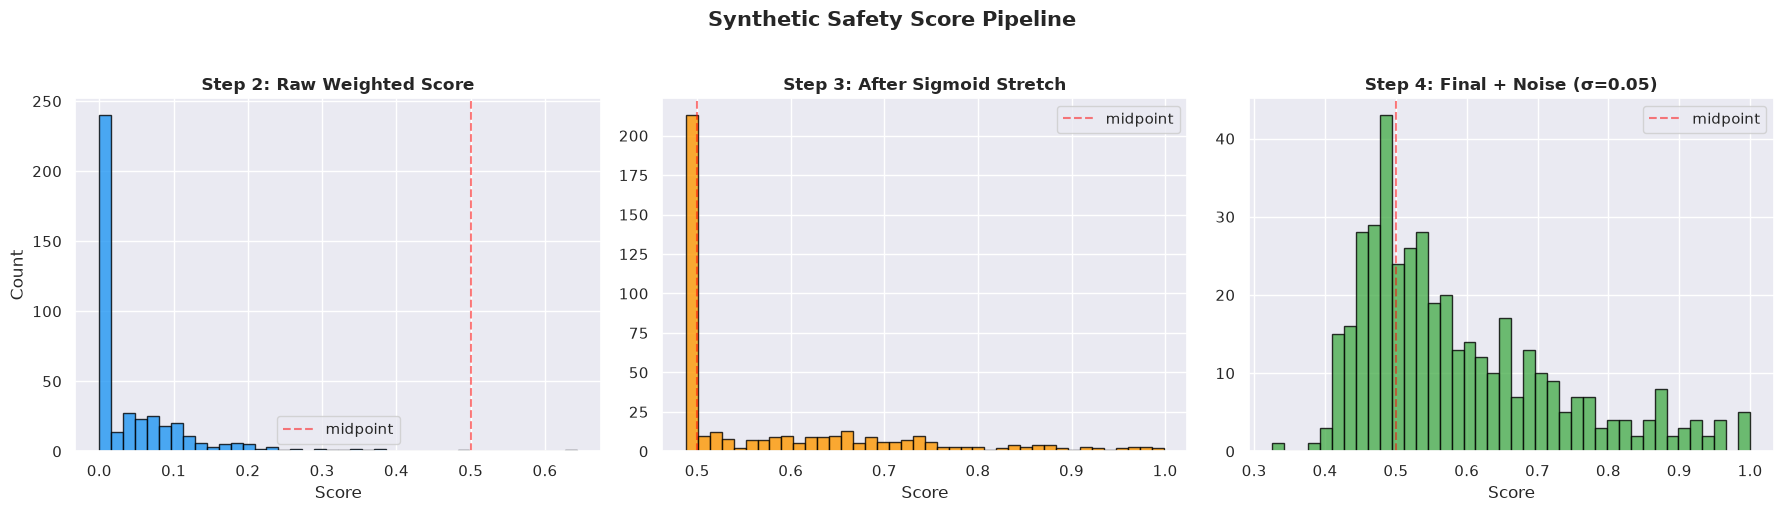

In [10]:
# ── Distribution comparison: raw → stretched → noisy ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['raw_score'], bins=40, color='#2196F3', edgecolor='black', alpha=0.8)
axes[0].set_title('Step 2: Raw Weighted Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

axes[1].hist(df['stretched_score'], bins=40, color='#FF9800', edgecolor='black', alpha=0.8)
axes[1].set_title('Step 3: After Sigmoid Stretch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score')

axes[2].hist(df['target_safety_score'], bins=40, color='#4CAF50', edgecolor='black', alpha=0.8)
axes[2].set_title(f'Step 4: Final + Noise (σ={NOISE_SIGMA})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Score')

for ax in axes:
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='midpoint')
    ax.legend()

plt.suptitle('Synthetic Safety Score Pipeline', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

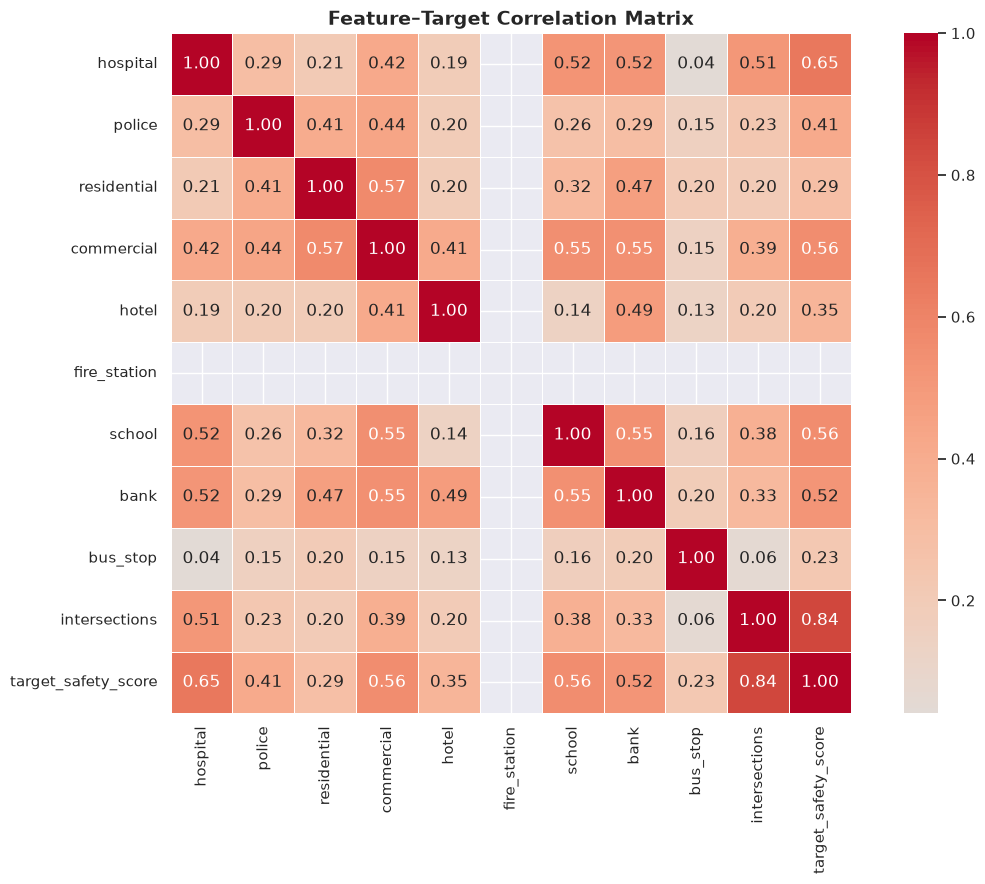

In [11]:
# ── Correlation heatmap: features vs target ────────────
corr_cols = FEATURE_COLS + ['target_safety_score']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5, ax=ax,
    xticklabels=[c.replace('count_', '') for c in corr_cols],
    yticklabels=[c.replace('count_', '') for c in corr_cols],
)
ax.set_title('Feature–Target Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── Sanity check: top-5 safest and least-safe cells ────
print('\n─── TOP 5 SAFEST CELLS ─────────────────────────')
top5 = df.nlargest(5, 'target_safety_score')
display(top5[['hex_id', 'centroid_lat', 'centroid_lng'] + FEATURE_COLS + ['target_safety_score']])

print('\n─── TOP 5 LEAST SAFE CELLS ─────────────────────')
bottom5 = df.nsmallest(5, 'target_safety_score')
display(bottom5[['hex_id', 'centroid_lat', 'centroid_lng'] + FEATURE_COLS + ['target_safety_score']])


─── TOP 5 SAFEST CELLS ─────────────────────────


,hex_id,centroid_lat,centroid_lng,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections,target_safety_score
82,883c138cc7fffff,25.621481,85.120562,7,0,7,14,2,0,1,10,0,247,1.0
138,883c138ccdfffff,25.628548,85.106820,5,2,47,68,1,0,4,11,1,157,1.0
229,883c138c1bfffff,25.628456,85.097436,2,3,0,15,2,0,1,1,0,154,1.0
378,883c138cb3fffff,25.600266,85.161788,13,0,0,10,1,0,5,10,0,154,1.0
391,883c138cebfffff,25.614230,85.115532,9,2,2,51,0,0,2,7,0,201,1.0



─── TOP 5 LEAST SAFE CELLS ─────────────────────


,hex_id,centroid_lat,centroid_lng,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections,target_safety_score
262,883c13b91dfffff,25.622365,85.214443,0,0,0,0,0,0,0,0,0,0,0.325793
382,883c1316e1fffff,25.557440,85.206697,0,0,0,0,0,0,0,0,0,0,0.381662
14,883c131759fffff,25.542327,85.130934,0,0,0,0,0,0,0,0,0,0,0.401611
13,883c138de9fffff,25.563367,85.070960,0,0,0,0,0,0,0,0,0,10,0.404336
223,883c138f37fffff,25.591721,85.025400,0,0,0,0,0,0,0,0,0,0,0.407221


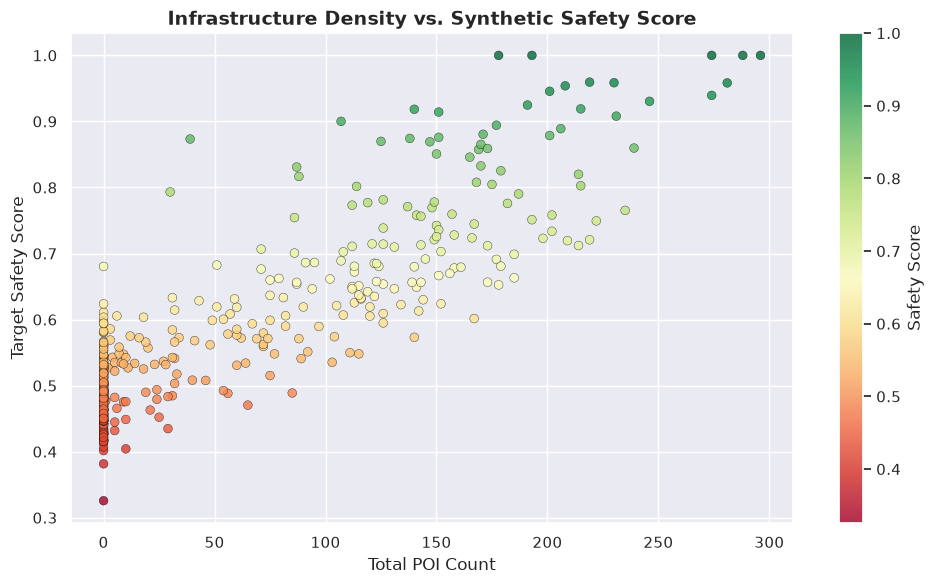

In [13]:
# ── Scatter: total_poi_count vs target_safety_score ────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df['total_poi_count'], df['target_safety_score'],
    c=df['target_safety_score'], cmap='RdYlGn',
    edgecolors='black', linewidths=0.3, alpha=0.8, s=40,
)
plt.colorbar(scatter, label='Safety Score')
ax.set_xlabel('Total POI Count', fontsize=12)
ax.set_ylabel('Target Safety Score', fontsize=12)
ax.set_title('Infrastructure Density vs. Synthetic Safety Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Export Training Dataset

The final CSV contains:
- `hex_id` — H3 cell identifier
- 10 feature columns — raw POI counts (the DNN input)
- `target_safety_score` — synthetic label (the DNN target)

This is consumed by `models/safety_dnn/train.py`.

In [14]:
# ── Select final columns for export ────────────────────
export_cols = ['hex_id'] + FEATURE_COLS + ['target_safety_score']
df_export = df[export_cols].copy()

# ── Save ────────────────────────────────────────────────
EXPORT_PATH = '../data/patna_synthetic_training_data.csv'
os.makedirs(os.path.dirname(EXPORT_PATH), exist_ok=True)
df_export.to_csv(EXPORT_PATH, index=False)

print(f'Exported {len(df_export):,} rows × {len(export_cols)} columns → {EXPORT_PATH}')
print(f'\nColumns: {list(df_export.columns)}')
print(f'Feature dims (DNN input_dim): {len(FEATURE_COLS)}')
df_export.describe().round(4)

Exported 422 rows × 12 columns → ../data/patna_synthetic_training_data.csv

Columns: ['hex_id', 'count_hospital', 'count_police', 'count_residential', 'count_commercial', 'count_hotel', 'count_fire_station', 'count_school', 'count_bank', 'count_bus_stop', 'count_intersections', 'target_safety_score']
Feature dims (DNN input_dim): 10


,count_hospital,count_police,count_residential,count_commercial,count_hotel,count_fire_station,count_school,count_bank,count_bus_stop,count_intersections,target_safety_score
count,422.0000,422.0000,422.0000,422.0000,422.0000,422.0,422.0000,422.0000,422.0000,422.0000,422.0000
mean,0.6469,0.0450,0.3483,1.7725,0.0806,0.0,0.2204,0.3697,0.0261,54.8341,0.5859
std,1.9016,0.2586,2.5548,6.8402,0.4393,0.0,0.7237,1.4961,0.2108,67.9958,0.1388
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.3258
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.4842
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,10.0000,0.5425
75%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,111.0000,0.6593
max,13.0000,3.0000,47.0000,68.0000,5.0000,0.0,5.0000,12.0000,3.0000,247.0000,1.0000


In [15]:
# ── Summary ─────────────────────────────────────────────
print('=' * 60)
print('  NOTEBOOK 02 — COMPLETE')
print('=' * 60)
print(f'  H3 cells         : {len(df_export):>6,}')
print(f'  Feature columns   : {len(FEATURE_COLS):>6}  (DNN input_dim)')
print(f'  Target column     : target_safety_score')
print(f'  Score range       : [{df_export["target_safety_score"].min():.4f}, {df_export["target_safety_score"].max():.4f}]')
print(f'  Score mean ± std  : {df_export["target_safety_score"].mean():.4f} ± {df_export["target_safety_score"].std():.4f}')
print(f'  Noise σ           : {NOISE_SIGMA}')
print(f'  Saved to          : {EXPORT_PATH}')
print('=' * 60)
print('\n→ Next: python -m models.safety_dnn.train --epochs 100')
print('        (or run notebook 03_safety_dnn_training.ipynb)')

  NOTEBOOK 02 — COMPLETE
  H3 cells         :    422
  Feature columns   :     10  (DNN input_dim)
  Target column     : target_safety_score
  Score range       : [0.3258, 1.0000]
  Score mean ± std  : 0.5859 ± 0.1388
  Noise σ           : 0.05
  Saved to          : ../data/patna_synthetic_training_data.csv

→ Next: python -m models.safety_dnn.train --epochs 100
        (or run notebook 03_safety_dnn_training.ipynb)
